## [Star Type Prediction]

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.decomposition import PCA

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import cross_val_score

# pd.set_option('display.max_rows', None)
# pd.set_option('display.max_columns', None)

In [16]:
df=pd.read_csv("stars.csv")

print(df)

     Temperature (K)  Luminosity(L/Lo)  Radius(R/Ro)  Absolute magnitude(Mv)  \
0               3068          0.002400        0.1700                   16.12   
1               3042          0.000500        0.1542                   16.60   
2               2600          0.000300        0.1020                   18.70   
3               2800          0.000200        0.1600                   16.65   
4               1939          0.000138        0.1030                   20.06   
..               ...               ...           ...                     ...   
235            38940     374830.000000     1356.0000                   -9.93   
236            30839     834042.000000     1194.0000                  -10.63   
237             8829     537493.000000     1423.0000                  -10.73   
238             9235     404940.000000     1112.0000                  -11.23   
239            37882     294903.000000     1783.0000                   -7.80   

     Star type Star color Spectral Clas

#### [Data Pre-Processing]

In [17]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 240 entries, 0 to 239
Data columns (total 7 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Temperature (K)         240 non-null    int64  
 1   Luminosity(L/Lo)        240 non-null    float64
 2   Radius(R/Ro)            240 non-null    float64
 3   Absolute magnitude(Mv)  240 non-null    float64
 4   Star type               240 non-null    int64  
 5   Star color              240 non-null    object 
 6   Spectral Class          240 non-null    object 
dtypes: float64(3), int64(2), object(2)
memory usage: 13.3+ KB
None


In [18]:
print(df.isnull().sum())

Temperature (K)           0
Luminosity(L/Lo)          0
Radius(R/Ro)              0
Absolute magnitude(Mv)    0
Star type                 0
Star color                0
Spectral Class            0
dtype: int64


In [19]:
print(df.describe())

       Temperature (K)  Luminosity(L/Lo)  Radius(R/Ro)  \
count       240.000000        240.000000    240.000000   
mean      10497.462500     107188.361635    237.157781   
std        9552.425037     179432.244940    517.155763   
min        1939.000000          0.000080      0.008400   
25%        3344.250000          0.000865      0.102750   
50%        5776.000000          0.070500      0.762500   
75%       15055.500000     198050.000000     42.750000   
max       40000.000000     849420.000000   1948.500000   

       Absolute magnitude(Mv)   Star type  
count              240.000000  240.000000  
mean                 4.382396    2.500000  
std                 10.532512    1.711394  
min                -11.920000    0.000000  
25%                 -6.232500    1.000000  
50%                  8.313000    2.500000  
75%                 13.697500    4.000000  
max                 20.060000    5.000000  


#### [Visualization]

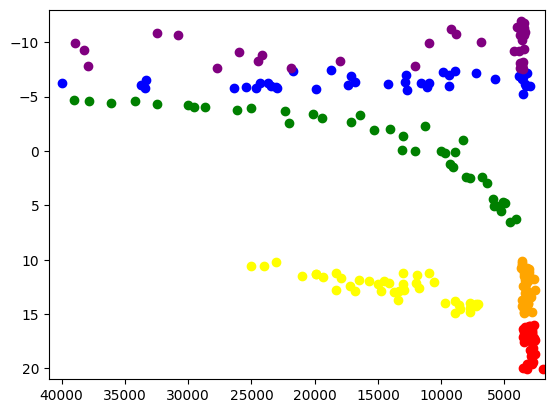

In [20]:
plt.scatter(x=df[df["Star type"]==0]["Temperature (K)"], y=df[df["Star type"]==0]["Absolute magnitude(Mv)"], color="Red")
plt.scatter(x=df[df["Star type"]==1]["Temperature (K)"], y=df[df["Star type"]==1]["Absolute magnitude(Mv)"], color="Orange")
plt.scatter(x=df[df["Star type"]==2]["Temperature (K)"], y=df[df["Star type"]==2]["Absolute magnitude(Mv)"], color="Yellow")
plt.scatter(x=df[df["Star type"]==3]["Temperature (K)"], y=df[df["Star type"]==3]["Absolute magnitude(Mv)"], color="Green")
plt.scatter(x=df[df["Star type"]==4]["Temperature (K)"], y=df[df["Star type"]==4]["Absolute magnitude(Mv)"], color="Blue")
plt.scatter(x=df[df["Star type"]==5]["Temperature (K)"], y=df[df["Star type"]==5]["Absolute magnitude(Mv)"], color="Purple")

plt.xlim([1800, 41000])
plt.ylim([-13, 21])
plt.gca().invert_xaxis()
plt.gca().invert_yaxis()

plt.show()

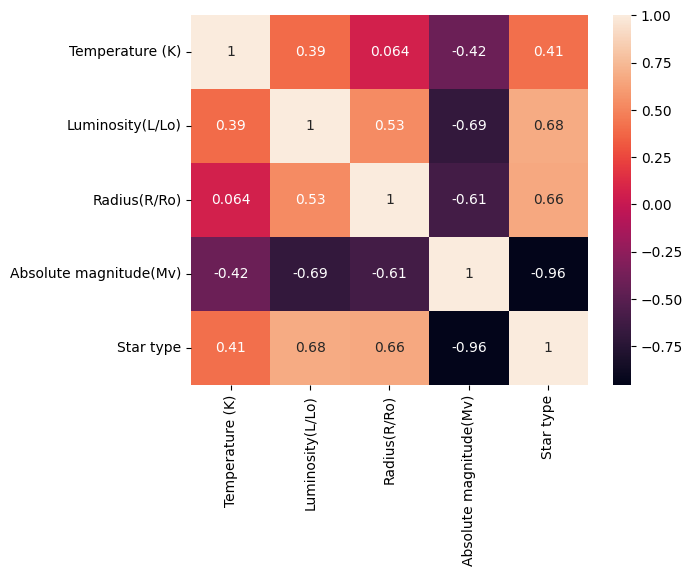

In [21]:
sns.heatmap(data=df[["Temperature (K)", "Luminosity(L/Lo)", "Radius(R/Ro)", "Absolute magnitude(Mv)", "Star type"]].corr(), annot=True)

plt.show()

#### [Model Training]

In [22]:
labelencoder=LabelEncoder()
df["Star color"]=labelencoder.fit_transform(df["Star color"])
df["Spectral Class"]=labelencoder.fit_transform(df["Spectral Class"])

print(df)

     Temperature (K)  Luminosity(L/Lo)  Radius(R/Ro)  Absolute magnitude(Mv)  \
0               3068          0.002400        0.1700                   16.12   
1               3042          0.000500        0.1542                   16.60   
2               2600          0.000300        0.1020                   18.70   
3               2800          0.000200        0.1600                   16.65   
4               1939          0.000138        0.1030                   20.06   
..               ...               ...           ...                     ...   
235            38940     374830.000000     1356.0000                   -9.93   
236            30839     834042.000000     1194.0000                  -10.63   
237             8829     537493.000000     1423.0000                  -10.73   
238             9235     404940.000000     1112.0000                  -11.23   
239            37882     294903.000000     1783.0000                   -7.80   

     Star type  Star color  Spectral Cl

In [23]:
features=df[["Temperature (K)", "Luminosity(L/Lo)", "Radius(R/Ro)", "Absolute magnitude(Mv)"]]
labels=df["Star type"]

print(features)
print(labels)

     Temperature (K)  Luminosity(L/Lo)  Radius(R/Ro)  Absolute magnitude(Mv)
0               3068          0.002400        0.1700                   16.12
1               3042          0.000500        0.1542                   16.60
2               2600          0.000300        0.1020                   18.70
3               2800          0.000200        0.1600                   16.65
4               1939          0.000138        0.1030                   20.06
..               ...               ...           ...                     ...
235            38940     374830.000000     1356.0000                   -9.93
236            30839     834042.000000     1194.0000                  -10.63
237             8829     537493.000000     1423.0000                  -10.73
238             9235     404940.000000     1112.0000                  -11.23
239            37882     294903.000000     1783.0000                   -7.80

[240 rows x 4 columns]
0      0
1      0
2      0
3      0
4      0
      .

In [24]:
standardscaler=StandardScaler()
features=standardscaler.fit_transform(features)

print(features)

[[-0.7793821  -0.59862356 -0.45920992  1.11674535]
 [-0.78210961 -0.59862357 -0.45924053  1.16241376]
 [-0.82847728 -0.59862357 -0.45934168  1.36221308]
 [-0.80749644 -0.59862357 -0.45922929  1.16717089]
 [-0.89781898 -0.59862357 -0.45933974  1.49160692]
 [-0.80330027 -0.59862357 -0.45932618  1.19856793]
 [-0.82459583 -0.59862357 -0.45929324  1.22140213]
 [-0.82847728 -0.59862357 -0.4593533   1.23852779]
 [-0.82323207 -0.59862357 -0.45932618  1.24328491]
 [-0.81798686 -0.59862357 -0.45928742  1.11008537]
 [-0.72357305 -0.59862355 -0.4585511   0.60012142]
 [-0.77298294 -0.5986235  -0.45881056  0.7047782 ]
 [-0.77245842 -0.59862357 -0.45915954  0.83988059]
 [-0.72063573 -0.59862354 -0.45877781  0.58014148]
 [-0.82323207 -0.59862357 -0.45926805  0.70401706]
 [-0.75084815 -0.59862355 -0.45907428  0.82656064]
 [-0.80760134 -0.59862356 -0.45922929  0.99020579]
 [-0.71392186 -0.59862355 -0.45862861  0.61058709]
 [-0.76637397 -0.59862355 -0.45915818  0.8703262 ]
 [-0.74025282 -0.59862335 -0.45

In [25]:
pca=PCA(n_components=2, random_state=42)
features=pca.fit_transform(features)

print(features)

[[-1.47609046e+00 -3.43210700e-01]
 [-1.50365409e+00 -3.43857077e-01]
 [-1.63628791e+00 -3.74995715e-01]
 [-1.51530901e+00 -3.64557320e-01]
 [-1.73591887e+00 -4.27500214e-01]
 [-1.53216893e+00 -3.59970271e-01]
 [-1.55290762e+00 -3.76697135e-01]
 [-1.56426810e+00 -3.79260576e-01]
 [-1.56518864e+00 -3.74802191e-01]
 [-1.48576772e+00 -3.75114760e-01]
 [-1.15539002e+00 -3.15573755e-01]
 [-1.23376021e+00 -3.52407597e-01]
 [-1.31241607e+00 -3.47112316e-01]
 [-1.14283419e+00 -3.13721431e-01]
 [-1.25113063e+00 -3.93458900e-01]
 [-1.29705145e+00 -3.29865559e-01]
 [-1.41229412e+00 -3.70755007e-01]
 [-1.15814158e+00 -3.07238683e-01]
 [-1.32801405e+00 -3.41062590e-01]
 [-1.18852517e+00 -3.27492750e-01]
 [-3.63612335e-01  1.52909765e+00]
 [-1.18825759e+00  5.27457435e-02]
 [-1.21899627e+00  8.61809263e-03]
 [-1.18693456e+00  1.19830374e-01]
 [-7.48440349e-01  8.00775323e-01]
 [-8.96224006e-01  4.99367897e-01]
 [-1.16774211e+00  1.24878325e-01]
 [-1.21465844e+00  5.07761982e-02]
 [-9.60251283e-01  3

In [26]:
train_features, test_features, train_labels, test_labels = train_test_split(features, labels, random_state=42)

In [27]:
dtclf=DecisionTreeClassifier(random_state=42)
dtclf.fit(train_features, train_labels)

rfclf=RandomForestClassifier(random_state=42)
rfclf.fit(train_features, train_labels)

logreg=LogisticRegression(random_state=42)
logreg.fit(train_features, train_labels)

LogisticRegression(random_state=42)

#### [Prediction]

In [29]:
# [Study] Cross Validation
print(np.mean(cross_val_score(dtclf, test_features, test_labels, cv=5)))
print(np.mean(cross_val_score(rfclf, test_features, test_labels, cv=5)))
print(np.mean(cross_val_score(logreg, test_features, test_labels, cv=5)))

0.8833333333333334
0.8833333333333334
0.8333333333333334
